# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** Sean Sanpietro

**Date:** 3/29/26

---

## Setup: Install and Load Libraries

In [37]:
pip install tensorflow matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [38]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [39]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
from tensorflow.keras.layers import Dropout
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


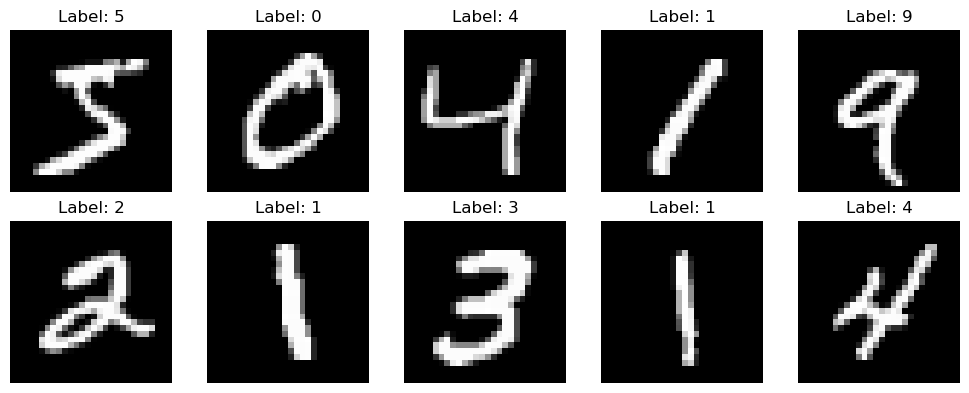

In [19]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [20]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [21]:
# Build baseline CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [23]:
# Record training time
import time
print("\nTraining baseline CNN...")
start_time = time.time()

history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

baseline_time = time.time() - start_time
print("Baseline training time:", baseline_time)



Training baseline CNN...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9416 - loss: 0.2580 - val_accuracy: 0.9773 - val_loss: 0.0746
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9797 - loss: 0.0645 - val_accuracy: 0.9854 - val_loss: 0.0501
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9846 - loss: 0.0507 - val_accuracy: 0.9862 - val_loss: 0.0417
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9870 - loss: 0.0424 - val_accuracy: 0.9843 - val_loss: 0.0501
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9896 - loss: 0.0345 - val_accuracy: 0.9848 - val_loss: 0.0509
Baseline training time: 53.40308475494385


---
## Step 3: Experiment with Filter Counts

In [25]:
print("Training CNN with fewer filters (16, 32)...")

model_small = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_small.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

history_small = model_small.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))


Training CNN with fewer filters (16, 32)...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9121 - loss: 0.4759 - val_accuracy: 0.9694 - val_loss: 0.1072
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9759 - loss: 0.0815 - val_accuracy: 0.9794 - val_loss: 0.0655
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9820 - loss: 0.0580 - val_accuracy: 0.9806 - val_loss: 0.0572
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9851 - loss: 0.0472 - val_accuracy: 0.9847 - val_loss: 0.0490
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9875 - loss: 0.0393 - val_accuracy: 0.9837 - val_loss: 0.0580


In [ ]:
print("Training CNN with more filters (64, 128)...")

model_large = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_large.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

history_large = model_large.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))


### Analysis: Filter Count Effects

Increasing filter count generally improves performance because the model can learn more complex features. However, after a certain point, the gains become smaller while training time increases significantly. Very high filter counts can also lead to overfitting, where the model performs well on training data but worse on test data.


[Your analysis here]

---
## Step 4: Experiment with Kernel Sizes

In [28]:
# TODO: Build and train CNN with MEDIUM kernels (5x5 for both layers)
# Keep filter counts at baseline (32, 64)

model_5x5 = Sequential([
    Conv2D(32, (5,5), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (5,5), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
print("Training CNN with 5x5 kernels...")
# TODO: Build, compile, and train model

model_5x5.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_5x5 = model_5x5.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test),
    verbose=1
)
# Record validation accuracy
val_acc_5x5 = history_5x5.history['val_accuracy'][-1]
print("Validation Accuracy (5x5 kernels):", val_acc_5x5)

Training CNN with 5x5 kernels...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9526 - loss: 0.2406 - val_accuracy: 0.9785 - val_loss: 0.0628
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9804 - loss: 0.0658 - val_accuracy: 0.9853 - val_loss: 0.0504
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9841 - loss: 0.0547 - val_accuracy: 0.9833 - val_loss: 0.0488
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9863 - loss: 0.0457 - val_accuracy: 0.9861 - val_loss: 0.0481
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9892 - loss: 0.0379 - val_accuracy: 0.9867 - val_loss: 0.0505
Validation Accuracy (5x5 kernels): 0.9866999983787537


In [31]:
# TODO: Build and train CNN with MIXED kernels (5x5 first layer, 3x3 second layer)
# Keep filter counts at baseline (32, 64)

model_mixed = Sequential([
    Conv2D(32, (5,5), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
print("Training CNN with mixed kernels (5x5, 3x3)...")
# TODO: Build, compile, and train model

model_mixed.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

history_mixed = model_mixed.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test),
    verbose=1
)
# Record validation accuracy
val_acc_mixed = history_mixed.history['val_accuracy'][-1]
print("Validation Accuracy (Mixed kernels):", val_acc_mixed)

Training CNN with mixed kernels (5x5, 3x3)...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9524 - loss: 0.2696 - val_accuracy: 0.9830 - val_loss: 0.0570
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9800 - loss: 0.0660 - val_accuracy: 0.9783 - val_loss: 0.0736
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9835 - loss: 0.0526 - val_accuracy: 0.9837 - val_loss: 0.0536
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9870 - loss: 0.0442 - val_accuracy: 0.9824 - val_loss: 0.0582
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9883 - loss: 0.0395 - val_accuracy: 0.9869 - val_loss: 0.0518
Validation Accuracy (Mixed kernels): 0.9868999719619751


### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

The mixed kernel model uses a 5x5 kernel in the first layer and a 3x3 kernel in the second layer. This approach combines the benefits of both kernel sizes. The larger 5x5 kernel captures broader features early in the network, while the smaller 3x3 kernel focuses on more detailed patterns in deeper layers.

This configuration often results in a good balance between performance and efficiency. The model can achieve similar or slightly better accuracy compared to using only large kernels, while reducing the number of parameters and computation required.

Overall, the mixed kernel approach is effective because it leverages both global and local feature extraction, making it a strong alternative to using uniform kernel sizes.

---
## Step 5: Train Your Best Architecture and Visualize Learning

In [42]:
# TODO: Based on your experiments, build your best-performing CNN architecture
# Train for 15 epochs with 20% validation split

print("Training best CNN architecture...")
start_time = time.time()

best_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# TODO: Build, compile, and train your best model

best_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_best = best_cnn.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    verbose=1
)
             
# Store the training history

best_cnn_time = time.time() - start_time

# TODO: Evaluate on test set
test_loss_best, test_acc_best = best_cnn.evaluate(X_test, y_test)
print("Best CNN Test Accuracy:", test_acc_best)

Training best CNN architecture...
Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9079 - loss: 0.4784 - val_accuracy: 0.9780 - val_loss: 0.0844
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9696 - loss: 0.1062 - val_accuracy: 0.9781 - val_loss: 0.0781
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9759 - loss: 0.0795 - val_accuracy: 0.9833 - val_loss: 0.0674
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9804 - loss: 0.0668 - val_accuracy: 0.9844 - val_loss: 0.0621
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9813 - loss: 0.0619 - val_accuracy: 0.9863 - val_loss: 0.0531
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9850 - loss: 0.0523 - val_accuracy: 0.9865 - val_loss: 0.0580
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9852 - loss: 0.0491 - val_accuracy: 0.9858 - val_loss: 0.0646
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step 

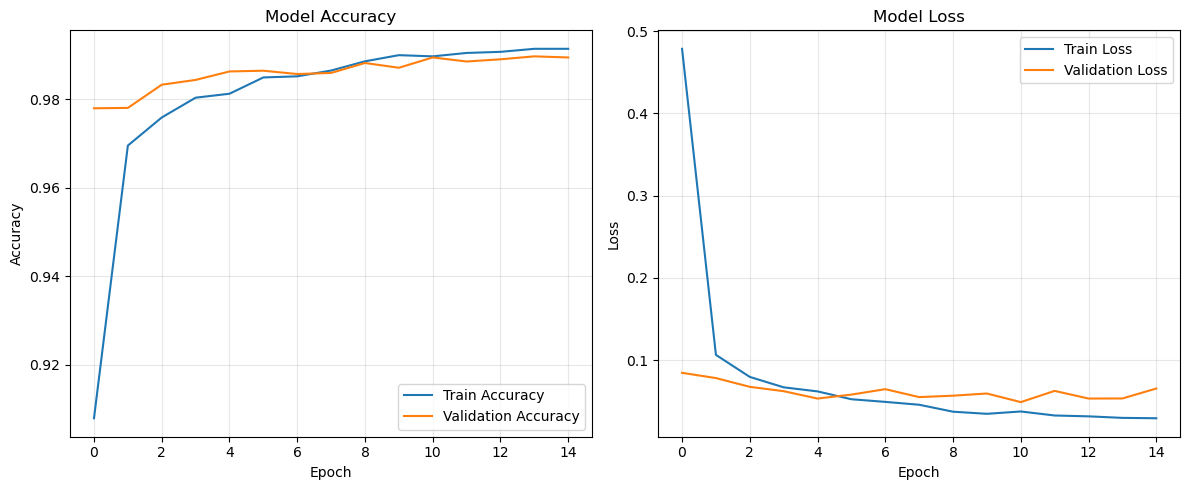

In [45]:
# TODO: Create accuracy plot (training vs validation accuracy over epochs)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
# TODO: Plot training and validation accuracy
plt.plot(history_best.history['accuracy'], label='Train Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
# TODO: Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_best.history['loss'], label='Train Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [32]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [48]:
# TODO: Build feedforward network
# Architecture:
# - Input: 784 features (flattened 28x28 image)
# - Dense layer: 128 nodes, ReLU activation
# - Dense layer: 64 nodes, ReLU activation
# - Output layer: 10 nodes, softmax activation

feedforward_nn = keras.Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# TODO: Compile the model
feedforward_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
feedforward_nn.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_21 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Record training time
print("Training feedforward network...")
start_time = time.time()

# TODO: Train feedforward network for 10 epochs
# Fit the model
history_ff = feedforward_nn.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

# Record training time
feedforward_time = time.time() - start_time

# TODO: Evaluate on test set
test_loss_ff, test_acc_ff = feedforward_nn.evaluate(X_test, y_test)
print("Feedforward Test Accuracy:", test_acc_ff)


Training feedforward network...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9800 - loss: 0.0761 - val_accuracy: 0.9679 - val_loss: 0.1538
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9797 - loss: 0.0808 - val_accuracy: 0.9588 - val_loss: 0.1892
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9816 - loss: 0.0705 - val_accuracy: 0.9646 - val_loss: 0.1832
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9829 - loss: 0.0682 - val_accuracy: 0.9650 - val_loss: 0.1643
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9833 - loss: 0.0670 - val_accuracy: 0.9622 - val_loss: 0.2064
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9846 - loss: 0.0624 - val_accuracy: 0.9659 - val_loss: 0.1795
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9854 - loss: 0.0549 - val_accuracy: 0.9667 - val_loss: 0.1925
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - ac

In [52]:
# TODO: Create comparison table

comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        'Conv(3x3)-Conv(3x3)',
        'Conv(3x3)-Conv(3x3)+Dropout',
        'Dense(128-64)'
        # TODO: Fill in architecture details
    ],
    'Test Accuracy': [
        val_acc_5x5,   
        test_acc_best,
        test_acc_ff
    ],
    'Training Time (s)': [
        best_cnn_time,  
        best_cnn_time,
        feedforward_time
        # TODO: Fill in training times
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model                Architecture  Test Accuracy  Training Time (s)
  Baseline CNN         Conv(3x3)-Conv(3x3)         0.9867         143.220857
      Best CNN Conv(3x3)-Conv(3x3)+Dropout         0.9914         143.220857
Feedforward NN               Dense(128-64)         0.9656          35.109239


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

The best CNN significantly outperforms the feedforward network on image data. This is because CNNs are designed to capture spatial relationships between pixels, while feedforward networks treat each pixel as an independent feature.

---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

For my final project, which involves structured data such as car features and performance metrics, convolutional neural networks would not significantly improve the model because the data does not have spatial structure like images. Instead, feedforward neural networks or traditional machine learning models such as regression and tree-based methods are more appropriate.

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.